In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("insurance - insurance.csv")

# Display first 10 rows
df.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [ ]:
# Shape of dataset
print("Shape of Dataset:", df.shape)

# Column names and data types
df.info()

# Statistical summary
df.describe()

Shape of Dataset: (1338, 7)
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [ ]:
# Count missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [ ]:
# Numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['age', 'bmi', 'children', 'expenses'], dtype='str')

Categorical Columns:
Index(['sex', 'smoker', 'region'], dtype='str')


C:\Users\chede appliances\AppData\Local\Temp\ipykernel_17396\1364943818.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


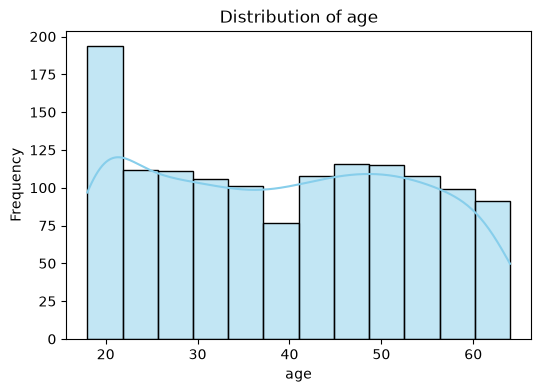

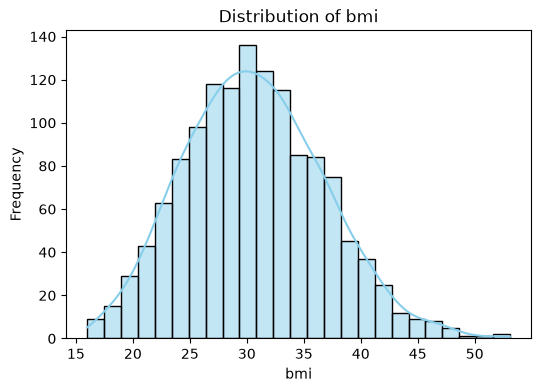

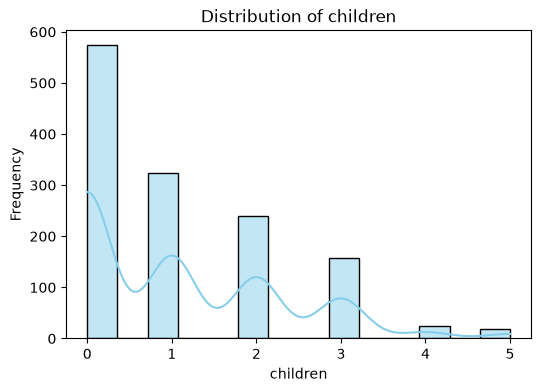

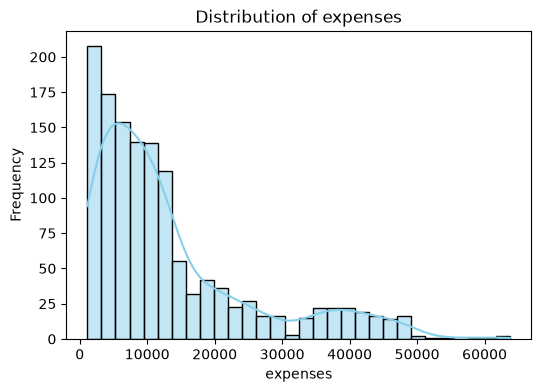

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numerical_columns = ['age', 'bmi', 'children', 'expenses']

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

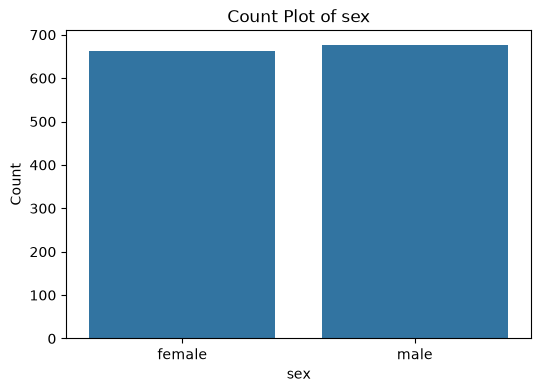

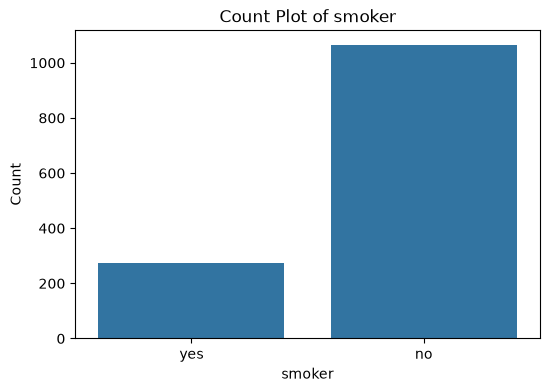

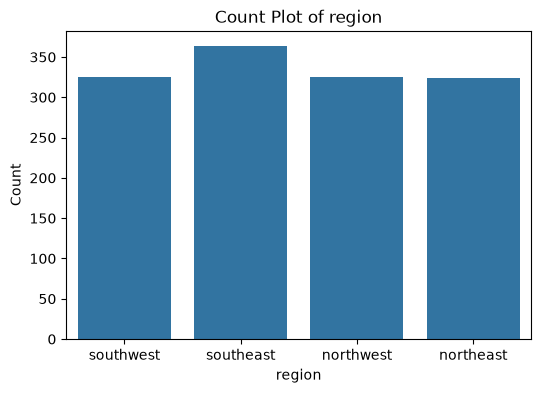

In [ ]:
categorical_columns = ['sex', 'smoker', 'region']

for col in categorical_columns:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

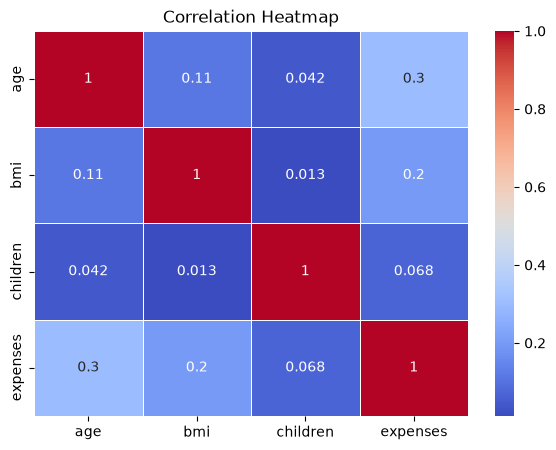

In [ ]:
plt.figure(figsize=(7,5))

corr = df[['age', 'bmi', 'children', 'expenses']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Average Expenses:", df['expenses'].mean())
print("Maximum Expenses:", df['expenses'].max())
print("Minimum Expenses:", df['expenses'].min())
smoker_expenses = df.groupby('smoker')['expenses'].mean()

print(smoker_expenses)

Average Expenses: 13270.422414050823
Maximum Expenses: 63770.43
Minimum Expenses: 1121.87
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


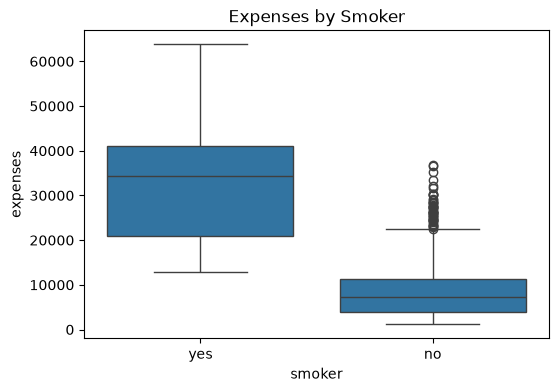

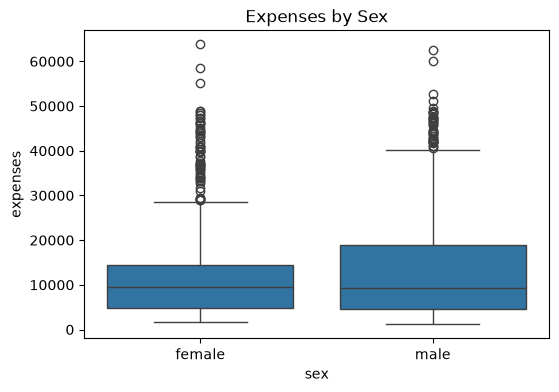

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(data=df,
            x='smoker',
            y='expenses')

plt.title("Expenses by Smoker")
plt.show()
plt.figure(figsize=(6,4))

sns.boxplot(data=df,
            x='sex',
            y='expenses')

plt.title("Expenses by Sex")
plt.show()

In [ ]:
print("Average Age:", df['age'].mean())

print("Average BMI:", df['bmi'].mean())

print("\nAverage Expenses by Smoking Status:")
print(df.groupby('smoker')['expenses'].mean())

print("\nRegion with Highest Customers:")
print(df['region'].value_counts())

print("\nObservations:")
print("1. Average age and BMI are shown above.")
print("2. Smokers have significantly higher insurance expenses than non-smokers.")
print("3. The region with the highest count is shown above.")
print("4. Expenses contain several high-value outliers, especially among smokers.")

Average Age: 39.20702541106129
Average BMI: 30.66547085201794

Average Expenses by Smoking Status:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64

Region with Highest Customers:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Observations:
1. Average age and BMI are shown above.
2. Smokers have significantly higher insurance expenses than non-smokers.
3. The region with the highest count is shown above.
4. Expenses contain several high-value outliers, especially among smokers.
